In [1]:
# Import all the functions you need
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sys
import os
from pathlib import Path

# Comment here to add in for either mac or linux computer
# sys.path.extend(['/Users/nkinsky/Documents/UM/GitHub/NeuroPy'])  # For mac laptop
sys.path.extend(['/data/GitHub/NeuroPy'])  # for linux

from neuropy import core
from neuropy.io import (optitrackio,
                        dlcio,
                        )
from neuropy.io.neuroscopeio import NeuroscopeIO
from neuropy.io.binarysignalio import BinarysignalIO 
from neuropy.io.miniscopeio import MiniscopeIO
from neuropy.core import Epoch, ProcessData
from neuropy.io.spykingcircusio import SpykingCircusIO

In [2]:
sess = ProcessData(os.getcwd())
print(sess.recinfo)

filename: /data3/Psilocybin/Recording_Rats/Finn/2022_02_15_saline1/Finn_saline1_denoised.xml 
# channels: 35
sampling rate: 30000
lfp Srate (downsampled): 1250



In [3]:
print(sess.eegfile)

duration: 3343.65 seconds 
duration: 0.93 hours 



# Preprocess Ephys data
Identify artifacts:  
- disconnects  
- filtering  
  
Send to event files to check in Neuroscope  
Write `dead_times.txt` file for spyking-circus and `artifacts.npy` file for my own analysis.

## Identify disconnect and motion artifacts

In [4]:
signal = sess.eegfile.get_signal()

In [5]:
from neuropy.analyses.artifact import detect_artifact_epochs

art_epochs_source_file = sess.filePrefix.with_suffix('.artifact.npy')

if art_epochs_source_file.is_file():
    art_epochs = Epoch(epochs=None, file=art_epochs_source_file)
    print('pre-existing epochs file loaded')
else:
    art_epochs = detect_artifact_epochs(signal, thresh=8, 
                                    edge_cutoff=2, merge=6)
    sess.recinfo.write_epochs(epochs=art_epochs, ext='art')
    art_epochs.save(art_epochs_source_file)


pre-existing epochs file loaded


/home/nkinsky/miniforge3/envs/NeuroPy/lib/python3.11/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


### Sanity check plot

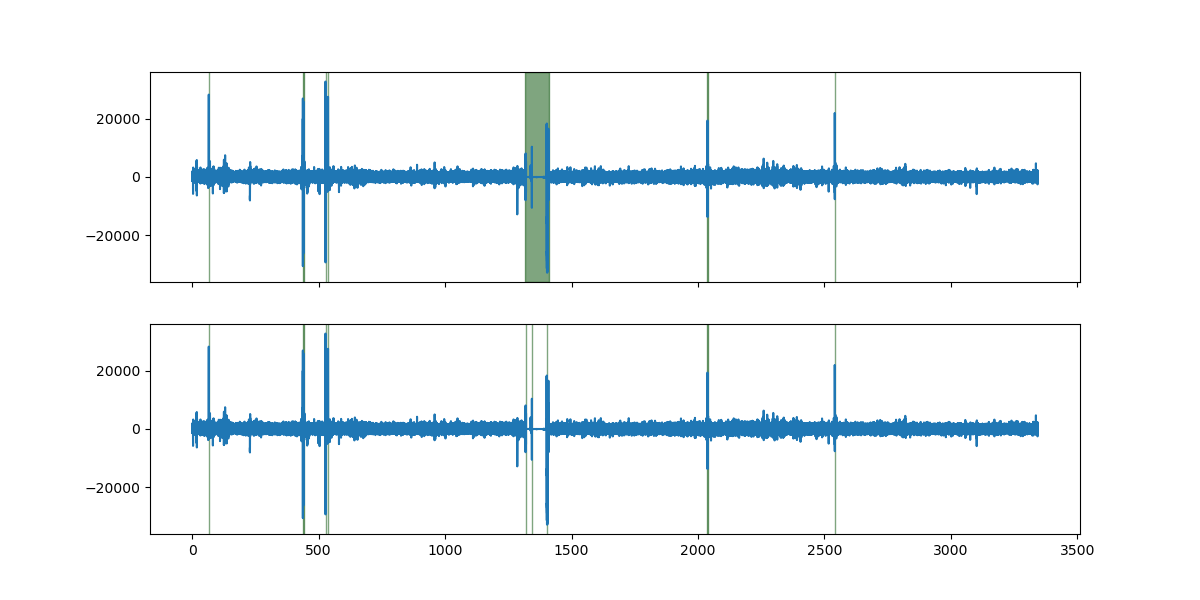

In [36]:
%matplotlib widget
from neuropy.plotting.signals import plot_signal_w_epochs
_, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True, sharey=True)
ax = axs[0]
plot_signal_w_epochs(signal, channel=27, epochs=art_epochs, ax=ax)

# Check vs ilknur artifacts
try:
    plot_signal_w_epochs(signal, channel=27, epochs=art_ilknur, ax=axs[1])
except NameError:
    pass


### Manually fix / add in any missing artifacts identified above.

In [ ]:
# from copy import deepcopy

# # Manually fix missing noise epoch in middle!
# art_list = [[1316, 1410.5], [1800, 1805]]  # This code would add in two artifact epochs from 1316-1410.5 and 1800-1805.
# art_epochs_fix = deepcopy(art_epochs)
# for (start, stop) in art_list:
#     art_epochs_fix = art_epochs_fix.add_epoch_manually(start, stop)

# sess.recinfo.write_epochs(epochs=art_epochs_fix, ext='art')
# art_epochs_fix.save(art_epochs_source_file)

In [ ]:
# # Alternate code to add in missing artifacts, e.g. from loosening of headstage not caught 
# # well by automatic artifact detection
# art_by_hand = Epoch(pd.DataFrame({"start": [246*60 + 31.1], "stop": [247*60 + 32.766], "label": "by_hand"}))

# art_epochs_combined = pd.concat((art_epochs._epochs, art_by_hand._epochs), 
#                                 keys=["start", "stop", "label"], ignore_index=True)
# art_epochs_combined = art_epochs_combined.sort_values(by='start', ignore_index=True)

### Add in a buffer before and after each epoch if desired.

In [ ]:
def add_epoch_buffer(epoch_df: pd.DataFrame, buffer_sec: float or int or tuple or list):
    """Extend each epoch by buffer_sec before/after start/stop of each epoch"""
    if type(buffer_sec) in [int, float]:
        buffer_sec = (buffer_sec, buffer_sec)
    else:
        assert len(buffer_sec) == 2
        
    epoch_df['start'] -= buffer_sec[0]
    epoch_df['stop'] += buffer_sec[1]

In [ ]:
add_epoch_buffer(art_epochs._epochs, 0.2)
sess.recinfo.write_epochs(art_epochs, 'art')
art_epochs._epochs

### Write `dead_times.txt` file for later processing with SpyKing Circus

In [ ]:
SpykingCircusIO.write_epochs(sess.basepath / 'dead_times.txt', 
                            art_epochs)

## Define probe group
You will have to vary the "columns", "contacts_per_column", "xpitch", "ypitch", and "channel_id" fields below to match your probe. The example below is for a 32 channel linear probe with electrode spacing of 50um.

In [ ]:
from neuropy.core import Shank, Probe, ProbeGroup
from neuropy.plotting import plot_probe
shank = Shank()
shank = shank.auto_generate(columns=1, contacts_per_column=32, xpitch=0,
                   ypitch=50, channel_id=np.arange(32, 0, -1))
shank.set_disconnected_channels(sess.recinfo.skipped_channels)
probe = Probe(shank)
prbgrp = ProbeGroup()
prbgrp.add_probe(probe)
plot_probe(prbgrp)
prbgrp.filename = sess.filePrefix.with_suffix(".probegroup.npy")
prbgrp.save(prbgrp.filename)
sess.prbgrp = prbgrp

In [ ]:
print( f'last spike time = {np.max([a.max() for a in sess.phy.spiketrains])}')
print(f'recording duration = {sess.eegfile.duration}')

Above is ok - disconnect for last bit of recording accounts for no spikes in the last 40ish seconds

In [ ]:
pyr_bool = np.bitwise_and(sess.phy.cluster_info['depth'] >= 100, sess.phy.cluster_info['depth'] <= 450)
cort_bool = np.bitwise_not(pyr_bool)

In [ ]:
np.concatenate((sess.phy.spiketrains[0:5], sess.phy.spiketrains[0:3])).shape

In [ ]:
from neuropy.core.neurons import Neurons
sess.pyr_neurons = Neurons(sess.phy.spiketrains[pyr_bool], t_stop=sess.eegfile.duration, sampling_rate=1,
                      neuron_type=sess.phy.cluster_info['q'])
npyr = pyr_bool.sum()
print('First ' + str(npyr) + ' neurons are pyramidal')
trains_all = np.concatenate((sess.phy.spiketrains[pyr_bool], sess.phy.spiketrains[cort_bool]))
sess.all_neurons = Neurons(trains_all, t_stop=sess.eegfile.duration, sampling_rate=1,
                      neuron_type=sess.phy.cluster_info['q'])

In [ ]:
sess.phy.cluster_info

Calculate MUA

In [ ]:
sess.mua = sess.pyr_neurons.get_mua(bin_size=0.05)

Import curated ripple data

In [ ]:
from neuropy.core.epoch import Epoch
sess.ripple = Epoch(epochs=None, file=sess.filePrefix.with_suffix('.ripple_curated.npy'))

In [ ]:
a = sess.ripple.to_dataframe()